В этом домашнем задании вам предстоит решить задачу сопоставления изображений методами метрического обучения. Необходимо обучить нейронную сеть поиску похожих автомобилей из датасета cars196. Учтите, что для формирования прогнозов на тестовой выборке вы не должны напрямую прогнозировать класс объекта (не используйте метод прямой классификации). Пример формирования прогнозов можно найти в блокноте: metric_learning.ipynb блок Faiss

В процессе решения необходимо выполнить следующие пункты:

1. Реализовать метрики: Precision@k, Recall@k, mAP (1 балл)  
2. Добавить обучение аугментации (1 балл)  
3. Обучить модель (2 балла)  
- При обучении используйте базовую модель, отличную от той, что использовалась на семинаре (не ResNet50)
- Добавить триплет-потерю (помните о грамотном формировании триплетов)  
- Рассчитать метрики из пункта 1  
4. Показать с помощью GradCAM, где модель допускает ошибку (1 балл)  

In [2]:
from PIL import Image
import cv2
import os
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device is:", device)

Device is: cuda


In [3]:
import scipy.io
mat = scipy.io.loadmat('/kaggle/input/hw7-cars196/devkit/devkit/cars_train_annos.mat')
fname_to_class = {fname:cl-1 for fname, cl in zip([i[0] for i in mat['annotations'][0]['fname']], 
                                                [i[0][0] for i in mat['annotations'][0]['class']])}
cars_meta = scipy.io.loadmat('/kaggle/input/hw7-cars196/devkit/devkit/cars_meta.mat')
id_to_car = {idx: car[0] for idx, car in enumerate(cars_meta['class_names'][0])}

In [4]:
ADD_PATH = '/kaggle/input/hw7-cars196/archive/cars_train/cars_train'

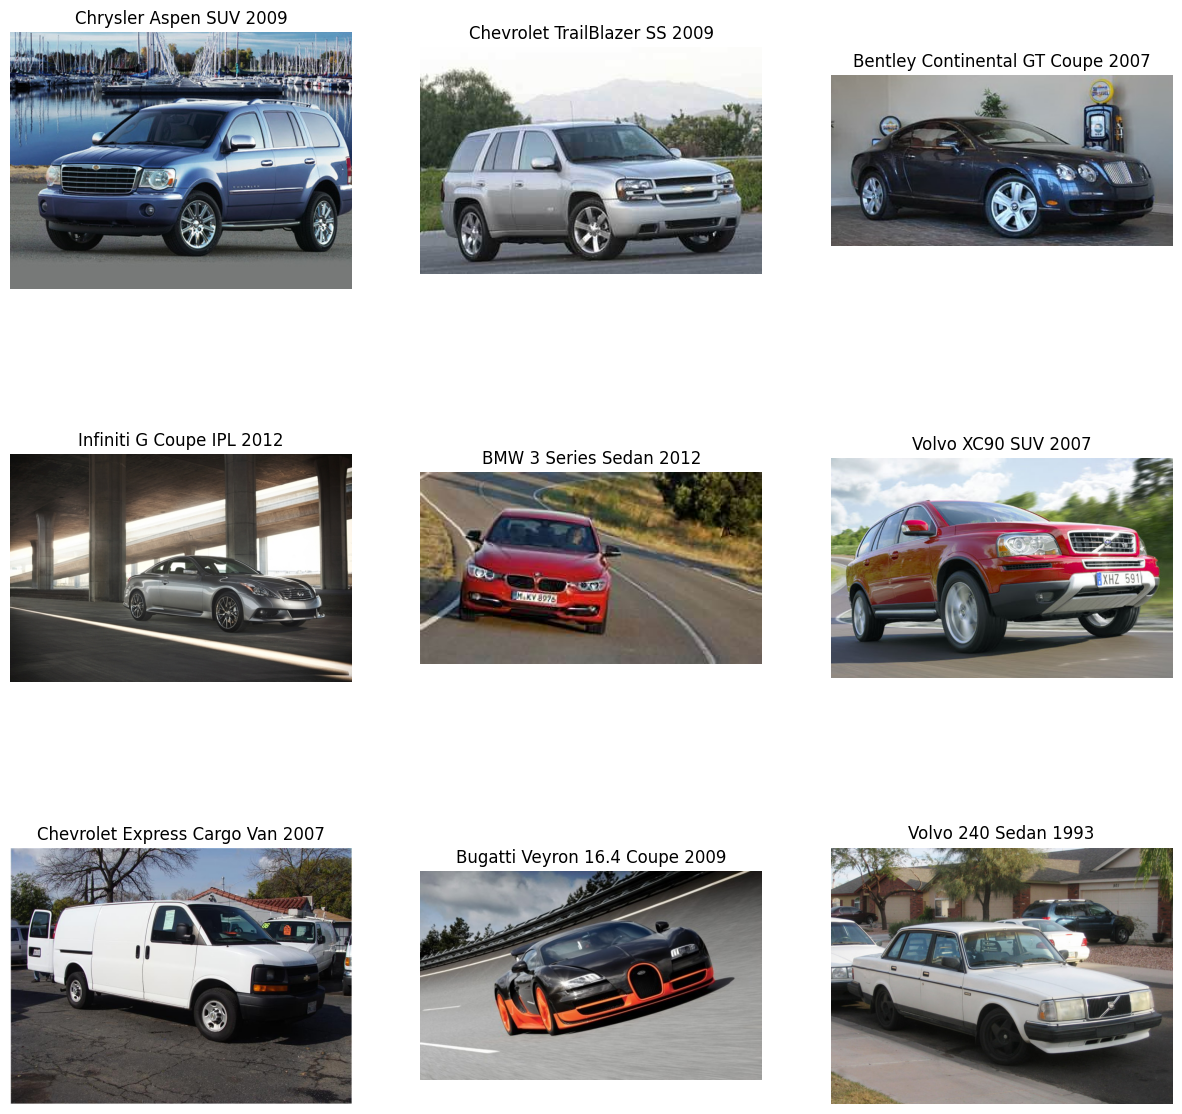

In [37]:
num_imgs = 9
cols = 3
rows = num_imgs // cols
fig, ax = plt.subplots(rows, cols, figsize = (15, 15))
for idx, im_idx in enumerate(random.sample([i for i in range(len(fname_to_class))], num_imgs)):
    filename, cl_id = list(fname_to_class.items())[im_idx]
    temp_image = cv2.imread(os.path.join(ADD_PATH, filename))
    temp_image = cv2.cvtColor(temp_image, cv2.COLOR_BGR2RGB)
    ax[idx//cols][idx%cols].imshow(temp_image)
    ax[idx//cols][idx%cols].set_title(f'{id_to_car[cl_id]}')
    ax[idx//cols][idx%cols].axis('off')

In [6]:
import torchvision
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToPILImage(),
    torchvision.transforms.Resize(
        size=(224, 224)
    ),
    torchvision.transforms.RandomRotation(degrees=10),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomGrayscale(p=0.05),
    torchvision.transforms.RandomApply([
        torchvision.transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ], p=0.3),
    torchvision.transforms.ToTensor(),  
    torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
    

val_transforms =  torchvision.transforms.Compose([
    torchvision.transforms.ToPILImage(), 
    torchvision.transforms.Resize(
        size=(224, 224)
    ),
    torchvision.transforms.ToTensor(),  
    torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CropClassifDataset(torch.utils.data.Dataset):
    def __init__(self, cars_items, transforms):
        self.cars = cars_items
        self.transforms = transforms
        
    def __len__(self):
        return len(self.cars)

    def __getitem__(self, idx):
        filename, cl_id = self.cars[idx]
        image = cv2.imread(os.path.join(ADD_PATH, filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transforms:
            image = self.transforms(image)
        sample = {'image': image, 'label': cl_id}
        return sample

In [7]:
items = list(fname_to_class.items())
random.shuffle(items)
train_items = items[:int(len(items) * 0.8)]
val_items = items[int(len(items) * 0.8):]

train_dataset = CropClassifDataset(train_items, train_transforms)
val_dataset = CropClassifDataset(val_items, val_transforms)

In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,pin_memory=True, drop_last = True)
valid_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        n = embeddings.size(0)

        dist = torch.cdist(embeddings, embeddings, p=2)

        mask_pos = labels.expand(n, n).eq(labels.expand(n, n).t())
        mask_neg = ~mask_pos

        losses = []
        for i in range(n):
            d_ap = dist[i][mask_pos[i]]
            d_an = dist[i][mask_neg[i]]
            if len(d_ap) == 0 or len(d_an) == 0:
                continue
            for dp in d_ap:
                semi = d_an[(d_an > dp) & (d_an < dp + self.margin)]
                if len(semi) > 0:
                    dn = semi.min()
                    loss_i = F.relu(dp - dn + self.margin)
                    losses.append(loss_i)

        return torch.mean(torch.stack(losses)) if losses else torch.tensor(0.0, requires_grad=True)

In [10]:
import lightning
import timm
from pytorch_metric_learning import losses, miners
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor

class CarEmbedder(pl.LightningModule):
    def __init__(self, class_dict, learning_rate=3e-4, emb_size=512, margin=0.3):
        super().__init__()
        self.learning_rate = learning_rate
        self.emb_size = emb_size
        self.margin = margin

        # чтобы вернуть фичи, num_classes=0
        self.model = timm.create_model('efficientnetv2_rw_s', pretrained=True, num_classes=0)  
        in_features = self.model.num_features

        self.embedding_head = nn.Sequential(
            nn.Linear(in_features, emb_size, bias=False),
            nn.BatchNorm1d(emb_size)
        )

        self.triplet_loss = losses.TripletMarginLoss(margin=self.margin)
        self.miner = miners.TripletMarginMiner(
            margin=self.margin, type_of_triplets="semi-hard"
        )

        self.save_hyperparameters()

    def training_step(self, batch, batch_idx):
        images = batch['image']
        labels = batch['label'].to(torch.long)
        embeddings = self.forward(images)

        hard_triplets = self.miner(embeddings, labels)
        loss = self.triplet_loss(embeddings, labels, hard_triplets)

        self.log("train_loss", loss, prog_bar=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images = batch['image']
        labels = batch['label'].to(torch.long)
        embeddings = self.forward(images)

        hard_triplets = self.miner(embeddings, labels)
        loss = self.triplet_loss(embeddings, labels, hard_triplets)

        self.log("validation_loss", loss, prog_bar=True, sync_dist=True)
        return {"emb": embeddings.detach(), "y": labels.detach()}

    def forward(self, images):
        feats = self.model(images)
        emb = self.embedding_head(feats)
        emb = F.normalize(emb, p=2, dim=1) 
        return emb

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return [optimizer]

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [11]:
# model
pl_model = CarEmbedder(id_to_car, 3e-4, 512)
checkpoint_callback = ModelCheckpoint(monitor='validation_loss',mode='min',  save_top_k=3)
early_stopping = EarlyStopping(monitor="validation_loss", mode="min", patience=2)
lr_monitor = LearningRateMonitor(logging_interval='step')

# train model
trainer = pl.Trainer(
    max_epochs=10, 
    accelerator=device,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor])

model.safetensors:   0%|          | 0.00/96.5M [00:00<?, ?B/s]

INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs


In [12]:
trainer.fit(model=pl_model, train_dataloaders=train_loader, 
            val_dataloaders=valid_loader)

2025-10-22 03:43:09.512961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761104589.758784      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761104589.822665      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name           | Type               | Params
------------------------------------------------------
0 | model          | EfficientNet       | 22.1 M
1 | embedding_head | Sequential         | 918 K 
2 | triplet_loss   | TripletMarginLoss  | 0     
3 | miner          | TripletMarginMiner | 0     
------------------------------------------------------
23.1 M    Trainable params


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [13]:
import tqdm

def get_embeds(model, loader, device="cpu"):
    model.eval()
    embeddings = np.empty((1, 512))
    labels = np.empty((1))
    for batch in tqdm.tqdm(loader):
        imgs = batch['image'].to(device)
        lbls = batch['label']
        with torch.no_grad():
            preds = model(imgs)         
        embeddings = np.concatenate([embeddings, preds.cpu().numpy()])
        labels = np.concatenate([labels, lbls.numpy()])
    return embeddings[1:].astype(np.float32), labels[1:]

In [16]:
def get_embeds(model, loader, device="cpu"):
    model = model.to(device)
    model.eval()
    embeddings = []
    labels = []
    for batch in tqdm.tqdm(loader):
        imgs = batch['image'].to(device)
        lbls = batch['label']
        with torch.no_grad():
            preds = model(imgs)
        embeddings.append(preds.cpu())
        labels.append(lbls)
    embeddings = torch.cat(embeddings).numpy().astype(np.float32)
    labels = torch.cat(labels).numpy().astype(np.int32)
    return embeddings, labels

In [26]:
train_emb, train_labels = get_embeds(pl_model, train_loader, device)
val_emb, val_labels = get_embeds(pl_model, valid_loader, device)

100%|██████████| 51/51 [00:17<00:00,  2.94it/s]


In [27]:
!pip install faiss-cpu

In [28]:
import faiss                   # make faiss available
index = faiss.IndexFlatL2(512)   # build the index
print(index.is_trained)
index.add(train_emb)                  # add vectors to the index
print(index.ntotal)

True
6496


In [29]:
k = 4                          # we want to see 4 nearest neighbors
D, I = index.search(train_emb[:5], k) # sanity check
print(I)
print(D)
D, I = index.search(val_emb, k)     # actual search
print(I[:5])                   # neighbors of the 5 first queries
print(I[-5:]) 

[[   0 5408 2966 3873]
 [   1  835 3055 4344]
 [   2  839 2159  643]
 [   3  712 3942 5744]
 [   4 5452 1824 1606]]
[[0.         0.06422133 0.08151963 0.08360448]
 [0.         0.0288228  0.04496706 0.04597287]
 [0.         0.02642574 0.03033552 0.03337575]
 [0.         0.02941878 0.03220254 0.03494199]
 [0.         0.0127536  0.01722862 0.01777263]]
[[3526  678 1756 1642]
 [4136 5964 2914 5448]
 [2301 4271 2237 1415]
 [2577 3233 3369  413]
 [6457 1061 3941  550]]
[[3851 1894 1076 3011]
 [4160 1100 6158 3612]
 [ 550 3793 1339 6402]
 [3923 1598 4715 3176]
 [2450 4866 1485 4987]]


In [30]:
def precision_at_k(I, train_labels, val_labels, k=1):
    correct = 0
    total = len(val_labels)
    for i in range(total):
        retrieved = train_labels[I[i, :k]]
        if val_labels[i] in retrieved:
            correct += 1
    return correct / total


def recall_at_k(I, train_labels, val_labels, k=1):
    recalls = []
    for i in range(len(val_labels)):
        true_class = val_labels[i]
        total_pos = np.sum(train_labels == true_class)
        retrieved = train_labels[I[i, :k]]
        hits = np.sum(retrieved == true_class)
        recalls.append(hits / total_pos if total_pos > 0 else 0)
    return np.mean(recalls)


def mean_average_precision(I, train_labels, val_labels):
    APs = []
    for i in range(len(val_labels)):
        true_class = val_labels[i]
        retrieved_classes = train_labels[I[i]]
        relevance = (retrieved_classes == true_class).astype(int)
        if relevance.sum() == 0:
            continue
        prec_at_k = np.cumsum(relevance) / (np.arange(len(relevance)) + 1)
        AP = (prec_at_k * relevance).sum() / relevance.sum()
        APs.append(AP)
    return np.mean(APs) if len(APs) > 0 else 0.0

In [31]:
k = 5
D, I = index.search(val_emb, k)

P5 = precision_at_k(I, train_labels, val_labels, k=k)
R5 = recall_at_k(I, train_labels, val_labels, k=k)
mAP = mean_average_precision(I, train_labels, val_labels)

print(f"k: {k}")
print(f"Precision@k: {P5:.4f}")
print(f"Recall@k:    {R5:.4f}")
print(f"mAP:          {mAP:.4f}")

k: 5
Precision@k: 0.2891
Recall@k:    0.0122
mAP:          0.5675


In [32]:
!pip install grad-cam

In [33]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

transform_to_show = torchvision.transforms.Compose([
    torchvision.transforms.ToPILImage(), 
    torchvision.transforms.Resize(
        size=(224, 224)
    ),
    torchvision.transforms.ToTensor()
])

def show_grad_cam(model, num_imgs):
    model = model.to(device)
    model.eval()
    cols = 3
    rows = num_imgs // cols
    fig, ax = plt.subplots(rows, cols, figsize=(15, 15))
    for idx, im_idx in enumerate(random.sample([i for i in range(len(fname_to_class))], num_imgs)):
        filename, cl_id = list(fname_to_class.items())[im_idx]
        temp_image = cv2.imread(os.path.join(ADD_PATH, filename))
        temp_image = cv2.cvtColor(temp_image, cv2.COLOR_BGR2RGB)
        rgb_im = np.array(transform_to_show(temp_image).permute(1, 2, 0))
        transformed_im = val_transforms(temp_image).unsqueeze(0).to(device)

        target_layers = [model.model.blocks[-1]]

        cam = GradCAM(model=model.model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=transformed_im)[0, :]
        visualization = show_cam_on_image(rgb_im, grayscale_cam, use_rgb=True)

        with torch.no_grad():
            emb = model(transformed_im).cpu().numpy()
        D, I = index.search(emb, 1)
        # класс ближайшего соседа
        pred_class = int(train_labels[I[0][0]])
        pred = id_to_car[pred_class]

        ax[idx//cols][idx%cols].imshow(visualization)
        ax[idx//cols][idx%cols].set_title(f'gt : {id_to_car[cl_id]} \n pred: {pred}')
        ax[idx//cols][idx%cols].axis('off')

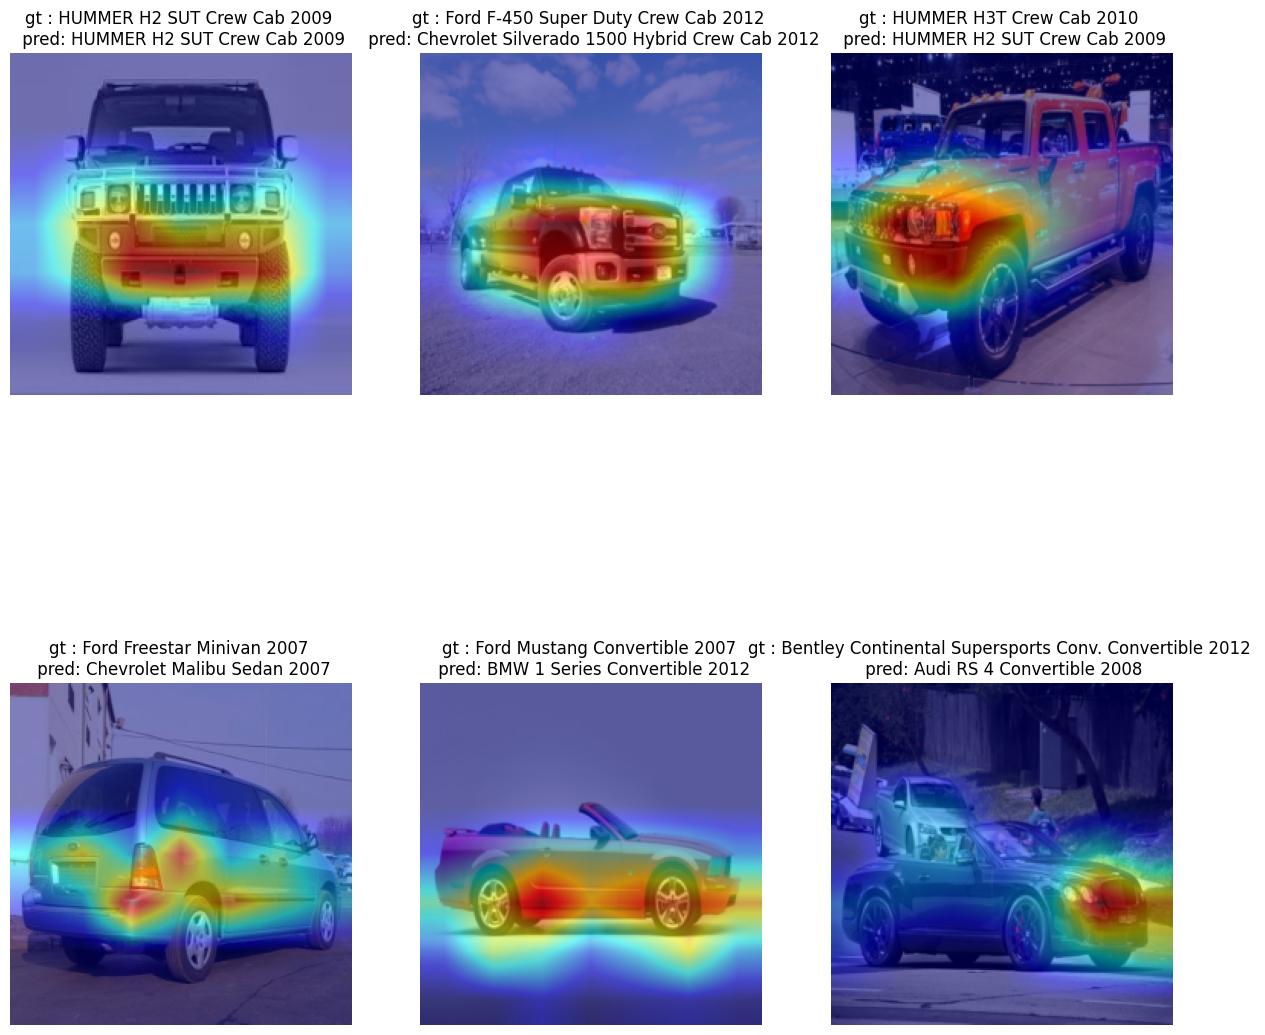

In [36]:
show_grad_cam(pl_model, num_imgs=6)

**Вывод:**  
Модель в основном смотрит на бампер, иногда на колеса, но в целом отделяет машины от фона.  
Вероятно, сейчас она путает машины похожие по дизайну.